In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier as KNC
from IPython.display import display

### Déclaration des données

In [ ]:
arbres = pd.read_csv("train.csv", index_col = 'ID_ARBRE')
arbres_trie = arbres[["type_sol", "classe_age", "classe_hauteur", "classe_circonference", "port_arbre", "vigueur_pousse", "plaie_collet", "fissure_tronc", "plaie_tronc", "fissure_houppier", "bois_mort_houppier", "plaie_houppier", "esperance_maintien"]]
y = arbres[["classification_diagnostic"]]

prev = pd.read_csv("prev.csv", index_col = 'ID_ARBRE')
prev_trie = prev[["type_sol", "classe_age", "classe_hauteur", "classe_circonference", "port_arbre", "vigueur_pousse", "plaie_collet", "fissure_tronc", "plaie_tronc", "fissure_houppier", "bois_mort_houppier", "plaie_houppier", "esperance_maintien"]]

### Fonction des Distances

In [54]:
# La fonction prend deux NP arrays de même taille
def distance_euclidienne(v1, v2):
    return np.sqrt(np.sum((v1 - v2)**2))

In [56]:
distance_euclidienne(np.array([2, 2]), np.array([1, 7]))

5.0990195135927845

In [58]:
# La fonction prend deux NP arrays de même taille
def distance_manhattan(v1, v2):
    return np.sum(np.abs((v1 - v2)))

### Encodage des données Arbres & Prev

In [61]:
new_arbres_trie = arbres_trie[
(arbres_trie["type_sol"] != "TV") & 
(arbres_trie["classe_age"] != "AM") & 
(arbres_trie["classe_hauteur"] != "H5") &
(arbres_trie["classe_circonference"] != "C5") &
(arbres_trie["classe_circonference"] != "C6") &
(arbres_trie["classe_circonference"] != "C7") &
(arbres_trie["vigueur_pousse"] != "D") &
(arbres_trie["plaie_collet"] != "AU") &
(arbres_trie["plaie_collet"] != "RCPLCF") &
(arbres_trie["plaie_collet"] != "RCPLNS") &
(arbres_trie["plaie_tronc"] != "TPLCF") &
(arbres_trie["plaie_tronc"] != "ZZ") &
(arbres_trie["plaie_houppier"] != "HPLC")

]

new_arbres_trie.head()

,type_sol,classe_age,classe_hauteur,classe_circonference,port_arbre,vigueur_pousse,plaie_collet,fissure_tronc,plaie_tronc,fissure_houppier,bois_mort_houppier,plaie_houppier,esperance_maintien
ID_ARBRE,,,,,,,,,,,,,
0,MA,A,H1,C1,R5,P,RCPPL,TPF,TPLS,HPF,HPBM,HPLS,1.0
1,MA,A,H2,C3,R5,P,RCPLS,TFO,TPLNC,HFO,HPBM,HPLNC,2.0
2,GR,A,H1,C2,R5,P,RCPPL,TPF,TPLC,HPF,HPBM,HPLS,1.0
3,Gr,A,H2,C3,R5,P,RCPLC,TPF,TPLC,HPF,HPBM,HPLS,1.0
4,MA,JA,H1,C1,L,P,RCPPL,TPF,TPLS,HPF,HPBM,HPPL,1.0


In [63]:
cat_features = ["port_arbre", "fissure_tronc", "fissure_houppier", "bois_mort_houppier"]

noncat_features = ["type_sol", "classe_age", "classe_hauteur", "classe_circonference", 
                   "vigueur_pousse", "plaie_collet", "plaie_tronc", "plaie_houppier"]

num_features = ["esperance_maintien"]

In [65]:
preprocesseur = ColumnTransformer(
    transformers = [
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), noncat_features),
    ('ord', OrdinalEncoder(), cat_features)]
)

arbres_hot = preprocesseur.fit_transform(arbres_trie)
colonnes = preprocesseur.get_feature_names_out()
arbres_hot = pd.DataFrame(arbres_hot, columns = colonnes)

prev_hot = preprocesseur.transform(prev_trie)
prev_hot = pd.DataFrame(prev_hot, columns = colonnes)

print("Arbres_hot :")
display(arbres_hot.head(3))
print("Prev_hot :")
display(prev_hot.head(3))

Arbres_hot :


,ohe__type_sol_CS,ohe__type_sol_G,ohe__type_sol_GR,ohe__type_sol_Gr,ohe__type_sol_MA,ohe__type_sol_P,ohe__type_sol_S,ohe__type_sol_TV,ohe__classe_age_A,ohe__classe_age_AM,...,ohe__plaie_tronc_ZZ,ohe__plaie_houppier_HPLC,ohe__plaie_houppier_HPLNC,ohe__plaie_houppier_HPLS,ohe__plaie_houppier_HPPL,ohe__plaie_houppier_ZZ,ord__port_arbre,ord__fissure_tronc,ord__fissure_houppier,ord__bois_mort_houppier
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,2.0,2.0,2.0,2.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0,1.0,2.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,2.0,2.0,2.0,2.0


Prev_hot :


,ohe__type_sol_CS,ohe__type_sol_G,ohe__type_sol_GR,ohe__type_sol_Gr,ohe__type_sol_MA,ohe__type_sol_P,ohe__type_sol_S,ohe__type_sol_TV,ohe__classe_age_A,ohe__classe_age_AM,...,ohe__plaie_tronc_ZZ,ohe__plaie_houppier_HPLC,ohe__plaie_houppier_HPLNC,ohe__plaie_houppier_HPLS,ohe__plaie_houppier_HPPL,ohe__plaie_houppier_ZZ,ord__port_arbre,ord__fissure_tronc,ord__fissure_houppier,ord__bois_mort_houppier
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,2.0,2.0,2.0,2.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0,2.0,2.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,2.0,2.0,2.0,2.0


### Classifieurs K-NN

In [68]:
def classifieur(X_values, df_encode, y, k_voisins):
    kpp = np.argsort([distance_euclidienne(X_values, df_encode.iloc[i]) for i in range(0, len(df_encode))])[0:k_voisins]
    k_classes = [y.iloc[i] for i in kpp]
    value, count = np.unique(k_classes, return_counts = True)
    return value[np.argmax(count)]

In [70]:
def classifieur_direct(X_to_predict, df_encode_train, y_train, k_voisins):
    len_df_encode = len(df_encode_train) #longueur du train_set.
    y_array = y_train.to_numpy() # version numpy du Pandas DataFrame y_train.
    X_values = X_to_predict.to_numpy()
    df_encode = df_encode_train.to_numpy()
    
    predictions = []
    for line in range(len(X_values)):
        distances_line = [distance_euclidienne(X_values[line], df_encode[i]) for i in range(0, len_df_encode)]
        kpp = np.argsort(distances_line)[0:k_voisins] #contient les indices des K-plus-proches distances/voisins
        
        # y_array[kpp] = vecteur contenant les k-plus-proches classes.
        # value = np.unique(y_array) et count = le nombre d'occurences des k-plus-proches classes. Une sorte de value_counts() de y_array[kpp].
        value, count = np.unique(y_array[kpp], return_counts = True)
        # np.argmax(count) contient l'inxex de l'élément qui apparait le plus.
        #On cherche dans value l'élément ayant le plus grand nb d'occurences grâce à np.argmax(count)
        predictions.append(value[np.argmax(count)])
    return predictions

#Prend plus de temps que classifieur classique (quelques secondes d'écart)

### Divisions en X_train, X_test, Y_train, Y_test

In [73]:
X_train, X_test, Y_train, Y_test = train_test_split(arbres_hot, y, test_size=0.20, random_state=None, shuffle=False)

In [75]:
X_train.head()

,ohe__type_sol_CS,ohe__type_sol_G,ohe__type_sol_GR,ohe__type_sol_Gr,ohe__type_sol_MA,ohe__type_sol_P,ohe__type_sol_S,ohe__type_sol_TV,ohe__classe_age_A,ohe__classe_age_AM,...,ohe__plaie_tronc_ZZ,ohe__plaie_houppier_HPLC,ohe__plaie_houppier_HPLNC,ohe__plaie_houppier_HPLS,ohe__plaie_houppier_HPPL,ohe__plaie_houppier_ZZ,ord__port_arbre,ord__fissure_tronc,ord__fissure_houppier,ord__bois_mort_houppier
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,2.0,2.0,2.0,2.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0,1.0,2.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,2.0,2.0,2.0,2.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,2.0,2.0,2.0,2.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,2.0,2.0,2.0


In [77]:
print("X_train :")
display(X_train.head(2))
print("X_test :")
display(X_test.head(2))

X_train :


,ohe__type_sol_CS,ohe__type_sol_G,ohe__type_sol_GR,ohe__type_sol_Gr,ohe__type_sol_MA,ohe__type_sol_P,ohe__type_sol_S,ohe__type_sol_TV,ohe__classe_age_A,ohe__classe_age_AM,...,ohe__plaie_tronc_ZZ,ohe__plaie_houppier_HPLC,ohe__plaie_houppier_HPLNC,ohe__plaie_houppier_HPLS,ohe__plaie_houppier_HPPL,ohe__plaie_houppier_ZZ,ord__port_arbre,ord__fissure_tronc,ord__fissure_houppier,ord__bois_mort_houppier
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,2.0,2.0,2.0,2.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0,1.0,2.0


X_test :


,ohe__type_sol_CS,ohe__type_sol_G,ohe__type_sol_GR,ohe__type_sol_Gr,ohe__type_sol_MA,ohe__type_sol_P,ohe__type_sol_S,ohe__type_sol_TV,ohe__classe_age_A,ohe__classe_age_AM,...,ohe__plaie_tronc_ZZ,ohe__plaie_houppier_HPLC,ohe__plaie_houppier_HPLNC,ohe__plaie_houppier_HPLS,ohe__plaie_houppier_HPPL,ohe__plaie_houppier_ZZ,ord__port_arbre,ord__fissure_tronc,ord__fissure_houppier,ord__bois_mort_houppier
435,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,2.0,2.0,2.0,2.0
436,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,3.0,2.0,2.0,2.0


### Prédiction Test set

In [80]:
predictions_test_set = classifieur_direct(X_test, arbres_hot, y, 3)

In [82]:
predictions_test_set

['C2',
 'C1',
 'C1',
 'C1',
 'C1',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C4',
 'C2',
 'C2',
 'C1',
 'C1',
 'C3',
 'C2',
 'C2',
 'C1',
 'C2',
 'C2',
 'C1',
 'C2',
 'C2',
 'C1',
 'C2',
 'C1',
 'C1',
 'C1',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C2',
 'C1',
 'C1',
 'C1',
 'C1',
 'C1',
 'C2',
 'C2',
 'C2',
 'C1',
 'C2',
 'C1',
 'C1',
 'C1',
 'C1',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C1',
 'C2',
 'C2',
 'C1',
 'C2',
 'C1',
 'C1',
 'C2',
 'C3',
 'C1',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C1',
 'C3',
 'C1',
 'C2',
 'C1',
 'C1',
 'C2',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C1',
 'C2',
 'C1',
 'C1',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C1',
 'C1',
 'C1',
 'C2',
 'C1',
 'C1',
 'C2',
 'C2',
 'C1',
 'C2',
 'C2',
 'C3']

### Taux de réussite

In [85]:
def are(predict, Y):
    erreurs = len([i for i, j in zip(predict, Y.to_numpy().flatten()) if i == j])
    taux = np.round((erreurs / len(Y)) * 100, 5)
    #print(f"Average Classification Accuracy : {taux}%")
    return taux

In [87]:
are(predictions_test_set, Y_test)

89.90826

### Fonctions pour trouver le meilleur nombre de voisins - K

In [90]:
def best_k(x_test, x_train, y_train):
    taux_reussite = 0
    best_k = 0
    best_score = 0
    scores_array = []
    for k in range(1, 20, 1):
        predictions = classifieur_direct(x_test, x_train, y_train, k)
        taux_reussite = are(predictions, Y_test)
        scores_array.append(taux_reussite)
        if taux_reussite > best_score:
            best_score = taux_reussite
            best_k = k
    return best_k, best_score, scores_array

In [92]:
best_k, best_score, scores_array = best_k(X_test, arbres_hot, y)

In [93]:
print("best k : ", best_k)
print("best score : ", best_score)

best k :  1
best score :  93.57798


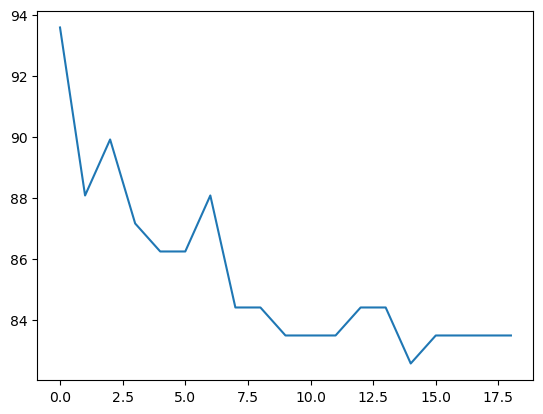

In [94]:
plt.plot(scores_array)

### Encodage et Feature Scaling sur Prev

In [1002]:
prev_encode_mms = mms.fit_transform(prev_encode)
prev_encode_mms = pd.DataFrame(prev_encode_mms, columns = noms_colonnes)
prev_encode_mms.head()

ValueError: Shape of passed values is (137, 13), indices imply (137, 59)

In [ ]:
prev_encode_std = std.fit_transform(prev_encode)
prev_encode_std = pd.DataFrame(prev_encode_std, columns = noms_colonnes)
prev_encode_std.head()

### Prédiction du dataset "prev"

In [99]:
previsions_prev_data = classifieur_direct(prev_hot, arbres_hot, y, 1)

In [100]:
previsions_prev_data

['C2',
 'C2',
 'C2',
 'C1',
 'C3',
 'C2',
 'C1',
 'C1',
 'C1',
 'C2',
 'C5',
 'C2',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C2',
 'C1',
 'C2',
 'C2',
 'C4',
 'C1',
 'C2',
 'C2',
 'C2',
 'C1',
 'C2',
 'C1',
 'C2',
 'C2',
 'C1',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C1',
 'C2',
 'C2',
 'C1',
 'C2',
 'C1',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C2',
 'C2',
 'C1',
 'C1',
 'C1',
 'C2',
 'C2',
 'C1',
 'C2',
 'C1',
 'C2',
 'C2',
 'C2',
 'C1',
 'C2',
 'C1',
 'C2',
 'C1',
 'C2',
 'C2',
 'C2',
 'C1',
 'C3',
 'C1',
 'C1',
 'C2',
 'C2',
 'C1',
 'C2',
 'C1',
 'C1',
 'C1',
 'C2',
 'C2',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C2',
 'C1',
 'C1',
 'C1',
 'C1',
 'C1',
 'C1',
 'C2',
 'C2',
 'C3',
 'C1',
 'C2',
 'C1',
 'C2',
 'C1',
 'C3',
 'C1',
 'C1',
 'C2',
 'C4',
 'C1',
 'C2',
 'C1',
 'C2',
 'C2',
 'C1',
 'C2',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C2',
 'C2',
 'C2',
 'C3',
 'C1',
 'C1',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C3',
 'C1',
 'C2',
 'C3',
 'C2',
 'C1',
 'C2']

### Cross Validation

In [104]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold, StratifiedKFold

In [106]:
model = KNC(n_neighbors = 1, metric='euclidean')

In [108]:
model.fit(X_train, Y_train["classification_diagnostic"])

KNeighborsClassifier(metric='euclidean', n_neighbors=1)

In [110]:
model.score(X_test, Y_test)

0.8532110091743119

In [111]:
previsions_sklearn = model.predict(prev_hot)

In [114]:
cv = KFold(7)

In [120]:
cross_validation_train = [cross_val_score(KNC(k), X_train, Y_train["classification_diagnostic"], cv=cv).mean() 
                          for k in range(1, 21)]

In [121]:
cross_validation_test = [cross_val_score(KNC(k), X_test, Y_test["classification_diagnostic"], cv=cv).mean() 
                         for k in range(1, 21)]

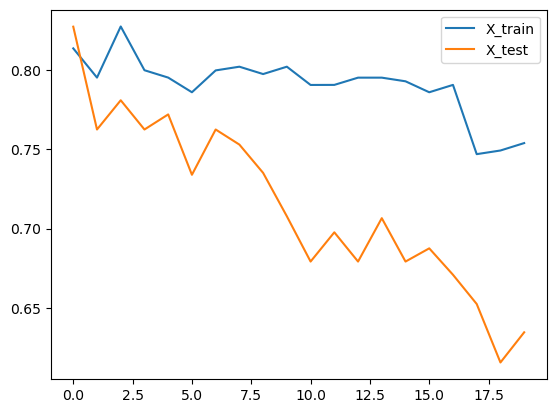

In [122]:
plt.plot(cross_validation_train, label="X_train")
plt.plot(cross_validation_test, label="X_test")
plt.legend()

In [152]:
k_values = range(1, 21)

# Courbes
cross_validation_train = [
    cross_val_score(KNC(k), X_train, Y_train["classification_diagnostic"], cv=5).mean()
    for k in k_values
]

test_scores = []
for k in k_values:
    model = KNC(k)
    model.fit(X_train, Y_train["classification_diagnostic"])
    score = model.score(X_test, Y_test["classification_diagnostic"])
    test_scores.append(score)

In [7]:
plt.plot(k_values, cross_validation_train, label="Score moyen en cross-validation (train)", color='blue')
plt.plot(k_values, test_scores, label="Score sur le test set", color='orange')
plt.xlabel("k")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'k_values' is not defined

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_sam

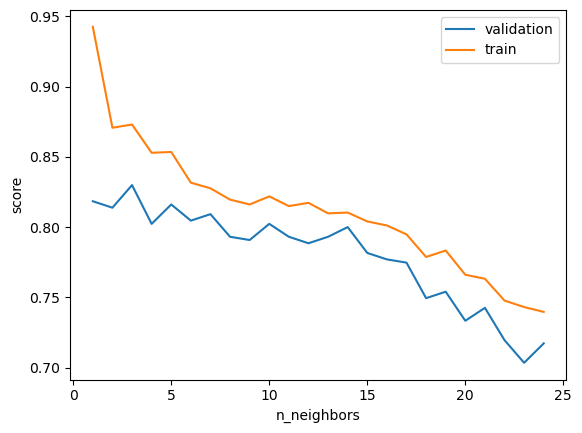

In [148]:
from sklearn.model_selection import validation_curve

model = KNC()
k = np.arange(1, 25)

train_score, val_score = validation_curve(
    model, X_train, Y_train, param_name='n_neighbors', param_range=k, cv=5
)

plt.plot(k, val_score.mean(axis=1), label='validation')
plt.plot(k, train_score.mean(axis=1), label='train')

plt.ylabel('score')
plt.xlabel('n_neighbors')
plt.legend()
     

### Submition

In [1105]:
sub = pd.DataFrame({'classification_diagnostic': previsions_prev_data})
sub.index.name = "ID_ARBRE"
id_arbre = prev_trie.index  # On récupère l'index chez x2
sub["ID_ARBRE"] = id_arbre  # Ajoute l'index comme colonne
sub = sub.set_index("ID_ARBRE")  # On définie 'ID_ARBRE' en tant qu'index

In [1111]:
sub.to_csv("sub_K1_Euclidean_arbres_hot_Onehot.csv")

In [1113]:
sub.head()

,classification_diagnostic
ID_ARBRE,
559,C2
560,C2
561,C2
562,C1
563,C3


### Cross Validation from scratch

In [ ]:
len(arbres_encode_std)/5

In [ ]:
folds = np.arange(1, 6, 1)
folds

In [ ]:
arbres_encode_std.iloc[: 108, :].head(2)

In [ ]:
X_train2, X_test2, Y_train2, Y_test2 = train_test_split(arbres_encode_std, y, test_size = 0.2, random_state=None, shuffle=False)

In [ ]:
debut = np.arange(0, 1, 0.25)
fin = np.arange(0.25, 1.25, 0.25)
print("debut : ", debut)
print("fin : ", fin)

In [ ]:
cross_vald = [max([are(classifieur_direct(X_train2.iloc[int(d*len(X_train2)):int(f*len(X_train2)), :], X_train2, Y_train2, k), Y_train2.iloc[int(d*len(X_train2)):int(f*len(X_train2)), :]) for d, f in zip(debut, fin)]) for k in range(1, 20)]

In [ ]:
plt.plot(cross_vald)

In [ ]:
X_train2.to_numpy()[0]